In [1]:
from process_childes import extract_utterances_by_age_and_adult_folder, clean_chinese_utterances_simple
from sentence_transformers import SentenceTransformer
from collections import defaultdict
import numpy as np
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'  # or 'PingFang TC', 'HanaMinA', etc.
matplotlib.rcParams['axes.unicode_minus'] = False

import torch

/Users/deborahwatty/.pyenv/versions/3.12.6/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get the vectors

In [3]:
# Load the data
data = clean_chinese_utterances_simple(extract_utterances_by_age_and_adult_folder("Mandarin"))

In [4]:
model = SentenceTransformer("distiluse-base-multilingual-cased-v2")

In [5]:
target_chars = {"說", "去", "看", "吃", "喝", "給", "想", "拿", "聽", "跑", "睡", "坐", "哭", "走", "買", "畫", "玩", "帶", "知道", "喜歡"}

# Filter child utterances by age
filtered_by_age = {
    age: [utt for utt in utts if any(char in utt for char in target_chars)]
    for age, utts in data["child"].items()
    if utts
}

# Filter adult utterances
filtered_by_age["adult"] = [
    utt for utt in data["adult"] if any(char in utt for char in target_chars)
]


In [5]:
filtered_by_age.keys()

dict_keys([4, 5, 6, 3, 2, 7, 8, 9, 10, 1, 0, 'adult'])

In [6]:
for group, utts in filtered_by_age.items():
    print(group, len(utts))

4 4345
5 6711
6 5066
3 3819
2 1999
7 1332
8 320
9 187
10 152
1 533
0 75
adult 42864


In [6]:
# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained("bert-base-chinese")
model = BertModel.from_pretrained("bert-base-chinese")
model.eval()

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(21128, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [7]:
def get_character_embeddings_by_group(data, target_chars):
    from transformers import BertTokenizer, BertModel
    import torch

    tokenizer = BertTokenizer.from_pretrained("bert-base-chinese")
    model = BertModel.from_pretrained("bert-base-chinese")
    model.eval()

    result = {"child": {}, "adult": {char: [] for char in target_chars}}

    # Handle children by age
    for age, utterances in data["child"].items():
        age_result = {char: [] for char in target_chars}
        for utt in utterances:
            if not any(char in utt for char in target_chars):
                continue
            inputs = tokenizer(utt, return_tensors="pt", truncation=True)
            with torch.no_grad():
                outputs = model(**inputs)
            embeddings = outputs.last_hidden_state.squeeze(0)
            tokens = tokenizer.tokenize(utt)
            for i, token in enumerate(tokens):
                for char in target_chars:
                    if token == char:
                        age_result[char].append(embeddings[i].numpy())
        result["child"][age] = age_result

    # Handle adult group
    for utt in data["adult"]:
        if not any(char in utt for char in target_chars):
            continue
        inputs = tokenizer(utt, return_tensors="pt", truncation=True)
        with torch.no_grad():
            outputs = model(**inputs)
        embeddings = outputs.last_hidden_state.squeeze(0)
        tokens = tokenizer.tokenize(utt)
        for i, token in enumerate(tokens):
            for char in target_chars:
                if token == char:
                    result["adult"][char].append(embeddings[i].numpy())

    return result

In [8]:
char_embeddings_by_group = get_character_embeddings_by_group(data, target_chars)

KeyboardInterrupt: 

# Pickle the vectors

In [10]:
import os
import pickle

output_dir = "char_embeddings_by_group_all_new"
os.makedirs(output_dir, exist_ok=True)

for char, groups in char_embeddings_by_group.items():
    for group, vectors in groups.items():
        filename = f"{output_dir}/{char}_{group}.pkl"
        with open(filename, "wb") as f:
            pickle.dump(vectors, f)


# Test PCA and plotting 

In [11]:
from sklearn.decomposition import PCA
import numpy as np

def reduce_embeddings(embeddings, n_components=2):
    all_vectors = np.vstack(embeddings)
    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(all_vectors)
    return reduced


In [12]:
# Flatten all embeddings to reduce them together
group_labels = []
char_labels = []
vectors = []

for group, chars in char_embeddings_by_group.items():
    for char, embs in chars.items():
        for emb in embs:
            emb = np.array(emb)
            if emb.shape == (768,):  # Keep only valid embeddings
                vectors.append(emb)
                group_labels.append(group)
                char_labels.append(char)

# Reduce to 2D
reduced_vectors = reduce_embeddings(vectors)


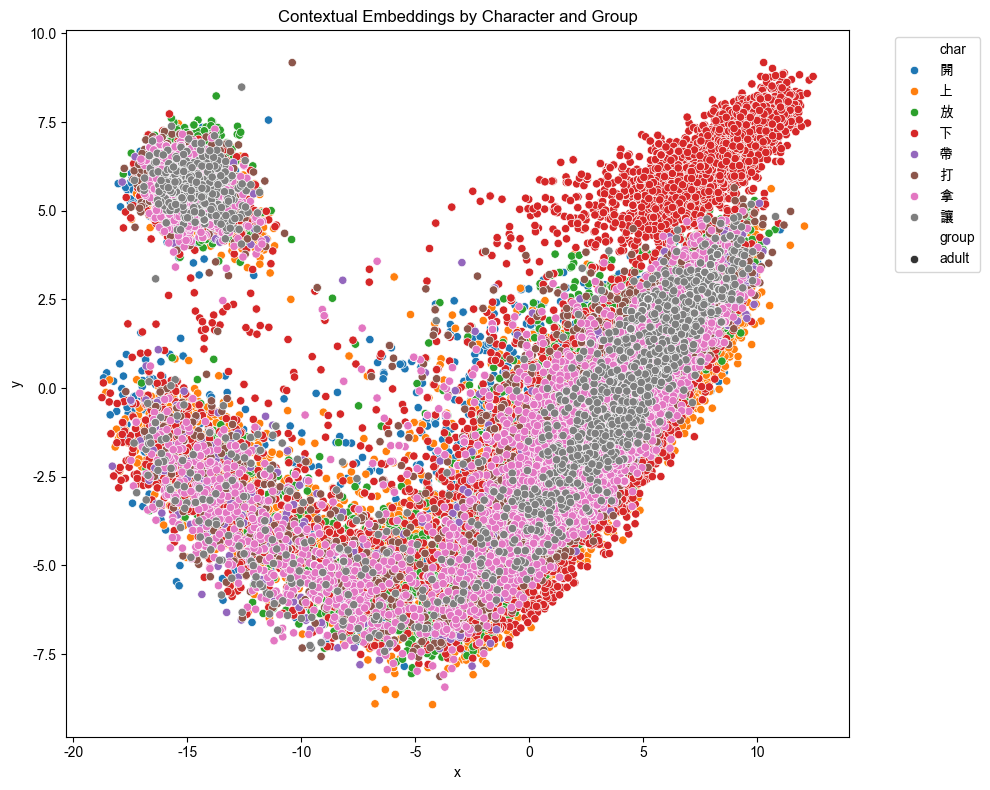

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Chinese characters display correctly
plt.rcParams["font.family"] = "Arial Unicode MS"  # or another font that supports Chinese

def plot_reduced_embeddings(reduced_vectors, group_labels, char_labels):
    plt.figure(figsize=(10, 8))
    df = {
        "x": [vec[0] for vec in reduced_vectors],
        "y": [vec[1] for vec in reduced_vectors],
        "group": group_labels,
        "char": char_labels
    }
    sns.scatterplot(x="x", y="y", hue="char", style="group", data=df)
    plt.title("Contextual Embeddings by Character and Group")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_reduced_embeddings(reduced_vectors, group_labels, char_labels)


In [14]:
char_embeddings_by_group.keys()

dict_keys(['child', 'adult'])

In [14]:
char_embeddings_by_group['child']

KeyboardInterrupt: 

In [20]:
data['child'][0]

['雞 雞',
 '嘎',
 '呱呱 呱',
 '小 牛',
 '小 貓',
 '小 山羊',
 '把 兔子 交 給 我',
 '要 講 這 個',
 '小 魚',
 '小 魚 遊',
 '沒有 了',
 '扔 地 上',
 '嗯',
 '玩 玩具',
 '運動',
 '在 地 下 玩',
 '門',
 '把 這 個 拆 開',
 '還有 一 個',
 '還有 一 個 沒收 進去',
 '玩 玩具',
 '拿 這 個 玩具',
 '好',
 '這 邊',
 '要',
 '不 要',
 '要 玩具',
 '這 個 是',
 '門',
 '不 要',
 '紅 顏色',
 '白 顏色',
 '黃 顏色',
 '花 顏色',
 '不 收 玩具',
 '玩',
 '我 要 玩',
 '玩玩',
 '這 是 什麼',
 '這 是',
 '玩具',
 '白 顏色',
 '不 收 玩具',
 '好',
 '那 這 個',
 '放 這 個 裡面',
 '放 這 個 裡面',
 '預備 齊',
 '呵呵',
 '飛機',
 '不 玩 飛機',
 '嗯',
 '這 是 什麼',
 '還有',
 '快點',
 '沒有',
 '沒有',
 '還有 還有',
 '呵呵',
 '飛機',
 '嗚嗚',
 '這 是 什麼',
 '藍 顏色',
 '還有 還有',
 '嗯',
 '嗯',
 '不 要',
 '這 是 什麼',
 '這 是 什麼',
 '掉',
 '圓圈',
 '圓圓 臉 喲',
 '啊嗚',
 '這 是 什麼',
 '這 是 什麼',
 '茶水',
 '呵呵',
 '不 好',
 '不 要',
 '飛機',
 '好',
 '查',
 '十 一',
 '五 六 只 筆',
 '不 要 不 要',
 '還 寫',
 '嗯',
 '上面',
 '不 要 不 要',
 '不 要 不 要',
 '這 個 不 要',
 '嗯',
 '我 要 這 只 寫',
 '呵呵',
 '圓圓的 臉',
 '小 金 魚 遊 啊 遊',
 '好',
 '這 個',
 '不 會',
 '嗯',
 '掉 了',
 '眉毛',
 '不 要 玩 飛機',
 '我 要 開',
 '呵呵',
 '洗 手',
 '沒關係',
 '不 好',
 '蓋子 呢',
 '沒有',
 '你 的 手 沒有',
 '來 來',
 '為什麼

# 2nd version of embeddings with utterances in the dictionary 
(this allows us to look at examples in each cluster) 

In [9]:


filtered_data = {
    "child": {
        age: [utt for utt in utts if any(char in utt for char in target_chars)]
        for age, utts in data["child"].items()
    },
    "adult": [
        utt for utt in data["adult"] if any(char in utt for char in target_chars)
    ]
}


def get_character_embeddings_by_group(data, target_chars):
    import torch
    from transformers import BertTokenizer, BertModel

    tokenizer = BertTokenizer.from_pretrained("bert-base-chinese")
    model = BertModel.from_pretrained("bert-base-chinese")
    model.eval()

    result = {"child": {}, "adult": {}}

    # Children by age
    for age, utterances in data["child"].items():
        group_result = {char: [] for char in target_chars}
        for utt in utterances:
            inputs = tokenizer(utt, return_tensors="pt", truncation=True, max_length=512)
            with torch.no_grad():
                outputs = model(**inputs)
            embeddings = outputs.last_hidden_state.squeeze(0)
            tokens = tokenizer.tokenize(utt)
            for i, token in enumerate(tokens):
                for char in target_chars:
                    if token == char:
                        group_result[char].append((embeddings[i].numpy(), utt))
        result["child"][age] = group_result

    # Adults
    group_result = {char: [] for char in target_chars}
    for utt in data["adult"]:
        inputs = tokenizer(utt, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            outputs = model(**inputs)
        embeddings = outputs.last_hidden_state.squeeze(0)
        tokens = tokenizer.tokenize(utt)
        for i, token in enumerate(tokens):
            for char in target_chars:
                if token == char:
                    group_result[char].append((embeddings[i].numpy(), utt))
    result["adult"] = group_result

    return result


In [10]:
char_embeddings_by_group = get_character_embeddings_by_group(filtered_data, list(target_chars))

In [11]:
# Summarize embeddings count
def summarize_embeddings(embeddings_by_group):
    for group in embeddings_by_group:
        print(f"Group: {group}")
        if group == "child":
            for age in sorted(embeddings_by_group[group]):
                print(f"  Age {age}:")
                for char, embeds in embeddings_by_group[group][age].items():
                    print(f"    {char}: {len(embeds)} embeddings")
        else:
            for char, embeds in embeddings_by_group[group].items():
                print(f"  {char}: {len(embeds)} embeddings")

summarize_embeddings(char_embeddings_by_group)


Group: child
  Age 0:
    去: 14 embeddings
    聽: 1 embeddings
    說: 5 embeddings
    跑: 7 embeddings
    玩: 32 embeddings
    畫: 11 embeddings
    給: 12 embeddings
    想: 6 embeddings
    知道: 0 embeddings
    帶: 3 embeddings
    走: 4 embeddings
    喜歡: 0 embeddings
    喝: 0 embeddings
    拿: 28 embeddings
    買: 4 embeddings
    哭: 5 embeddings
    看: 33 embeddings
    吃: 75 embeddings
    睡: 50 embeddings
    坐: 9 embeddings
  Age 1:
    去: 136 embeddings
    聽: 15 embeddings
    說: 18 embeddings
    跑: 37 embeddings
    玩: 83 embeddings
    畫: 57 embeddings
    給: 55 embeddings
    想: 20 embeddings
    知道: 0 embeddings
    帶: 17 embeddings
    走: 75 embeddings
    喜歡: 0 embeddings
    喝: 54 embeddings
    拿: 117 embeddings
    買: 70 embeddings
    哭: 28 embeddings
    看: 197 embeddings
    吃: 208 embeddings
    睡: 52 embeddings
    坐: 79 embeddings
  Age 2:
    去: 704 embeddings
    聽: 89 embeddings
    說: 133 embeddings
    跑: 91 embeddings
    玩: 419 embeddings
    畫: 259 embeddi

In [12]:
import os, pickle
os.makedirs("char_embeddings_by_group_all_with_utts_20", exist_ok=True)

for group in char_embeddings_by_group:
    for key, vectors in char_embeddings_by_group[group].items():
        filename = f"char_embeddings_by_group_all_with_utts_20/{group}_{key}.pkl"
        with open(filename, "wb") as f:
            pickle.dump(vectors, f)


In [2]:
import os
import pickle
from collections import defaultdict

input_dir = "char_embeddings_by_group_all_with_utts_20"
char_embeddings_by_group = defaultdict(lambda: defaultdict(list))

for filename in os.listdir(input_dir):
    if filename.endswith(".pkl"):
        char, group = filename.replace(".pkl", "").split("_")
        with open(os.path.join(input_dir, filename), "rb") as f:
            vectors = pickle.load(f)
            char_embeddings_by_group[char][group] = vectors


In [3]:
from load_embeddings import load_char_embeddings
char_embeddings_by_group = load_char_embeddings(input_dir="char_embeddings_by_group_all_with_utts_20")


In [4]:
char_embeddings_by_group['child']['8'].keys()

dict_keys(['去', '聽', '說', '跑', '玩', '畫', '給', '想', '知道', '帶', '走', '喜歡', '喝', '拿', '買', '哭', '看', '吃', '睡', '坐'])

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'Arial Unicode MS'  # or 'PingFang TC', 'HanaMinA', etc.
plt.rcParams['axes.unicode_minus'] = False

def plot_embeddings_pca(group_data, group_name):
    # Flatten and label
    embeddings = []
    labels = []
    for char, vecs in group_data.items():
        embeddings.extend([vec for vec, utt in vecs])
        labels.extend([char] * len(vecs))
    if len(embeddings) < 2:
        print(f"Not enough embeddings for {group_name}")
        return

    # Reduce
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(np.vstack(embeddings))

    # Plot
    fig = plt.figure(figsize=(6, 5))
    ls = list(set(labels))
    ls.sort()
    for char in ls:
        idxs = [i for i, lbl in enumerate(labels) if lbl == char]
        plt.scatter(reduced[idxs, 0], reduced[idxs, 1], label=char, s=3, alpha=1)
    plt.title(f"PCA - {group_name}")
    plt.legend()
    plt.ylim((-13,13))
    plt.xlim((-20,20))
    plt.grid(True)
    plt.show()
    return fig



In [6]:
import gc
gc.collect()


40

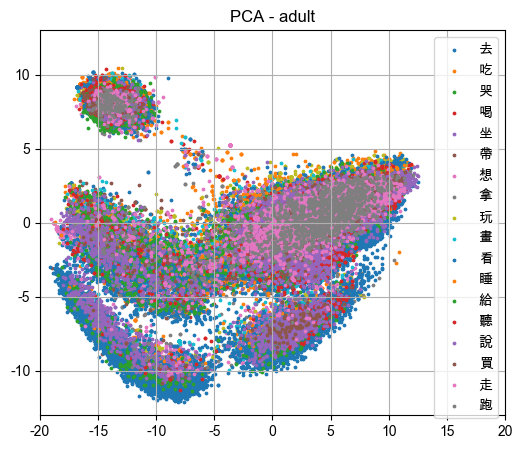

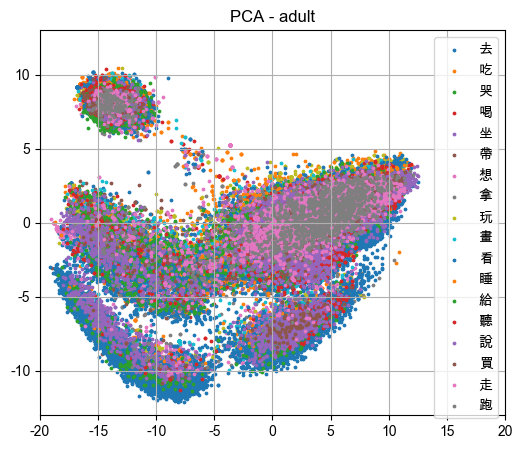

In [7]:
# Adults
plot_embeddings_pca(char_embeddings_by_group['adult'], 'adult')

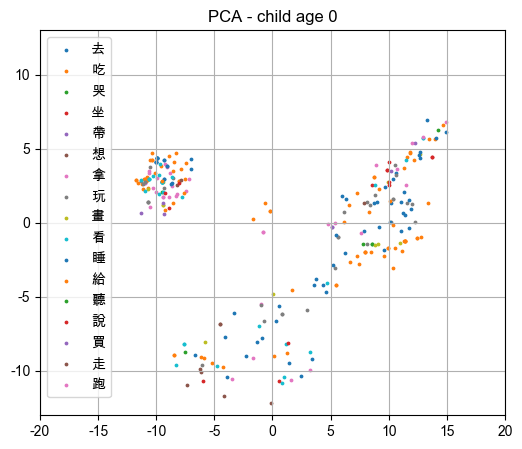

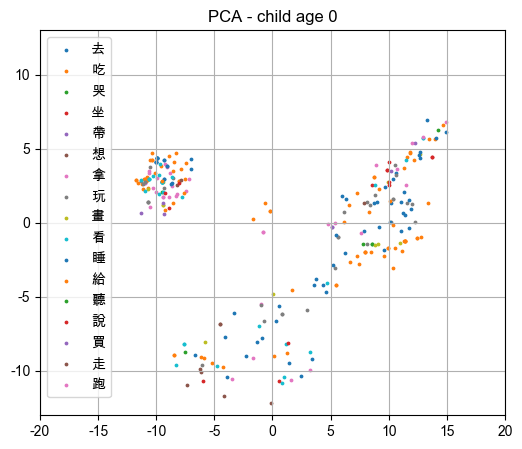

In [32]:
plot_embeddings_pca(char_embeddings_by_group['child']['0'], 'child age 0')

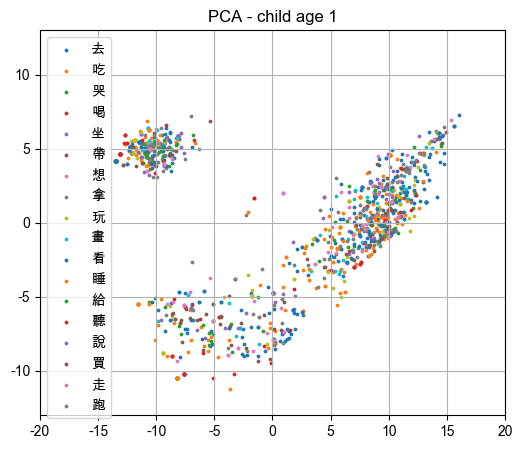

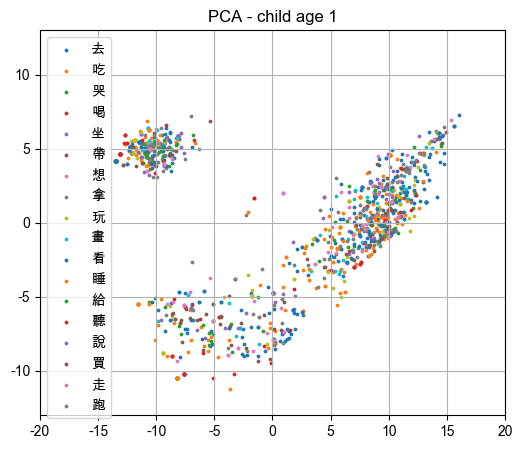

In [33]:
plot_embeddings_pca(char_embeddings_by_group['child']['1'], 'child age 1')

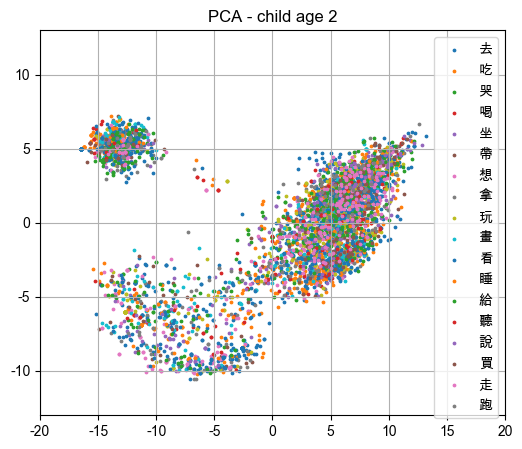

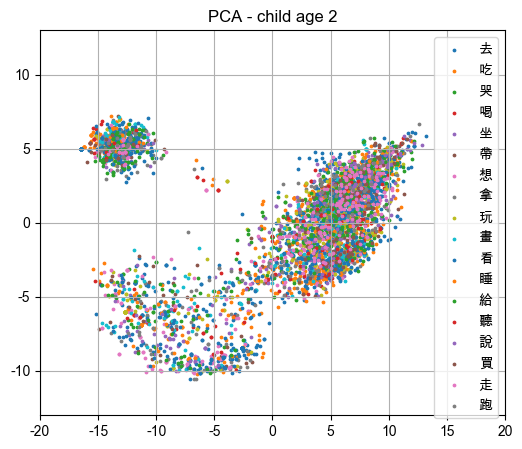

In [34]:
plot_embeddings_pca(char_embeddings_by_group['child']['2'], 'child age 2')

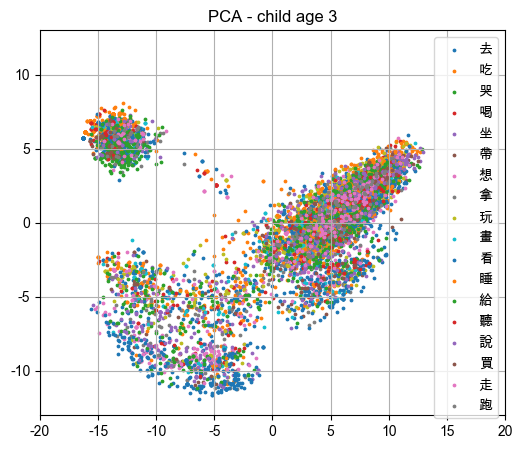

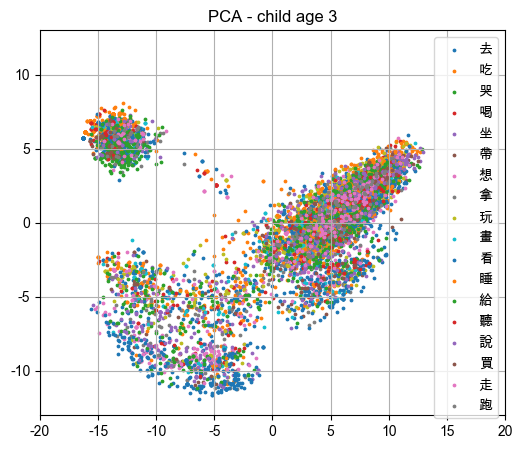

In [35]:
plot_embeddings_pca(char_embeddings_by_group['child']['3'], 'child age 3')

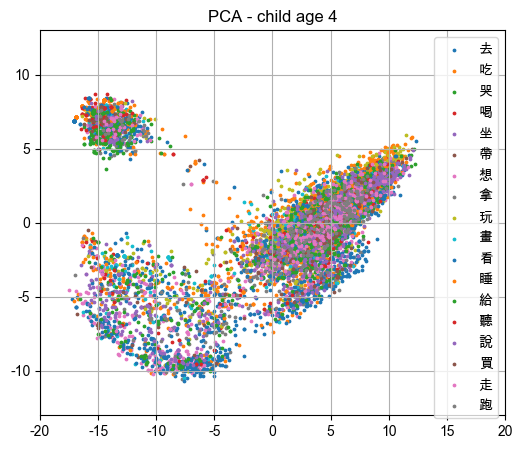

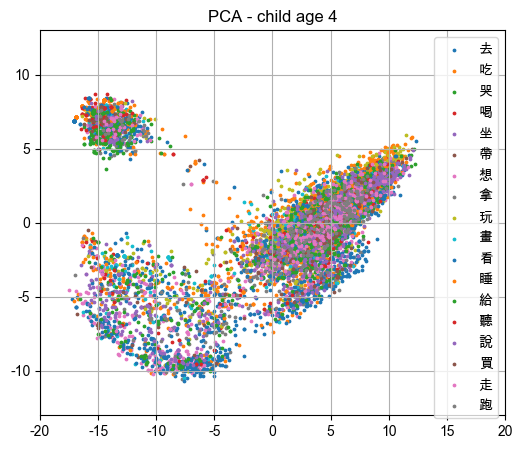

In [36]:
plot_embeddings_pca(char_embeddings_by_group['child']["4"], 'child age 4')

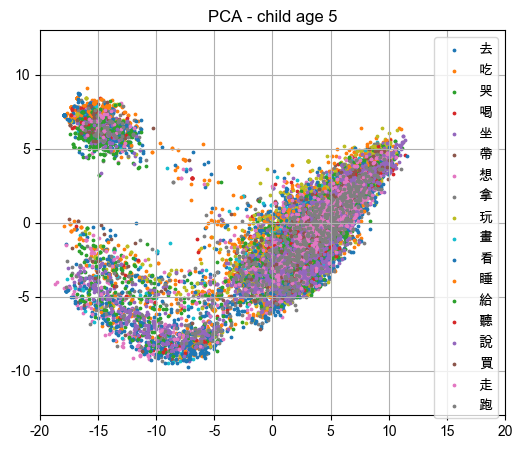

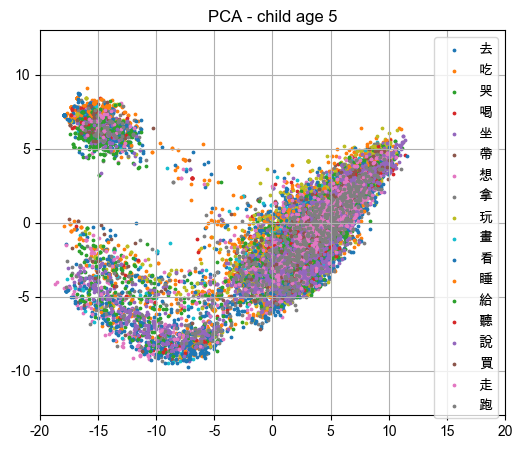

In [37]:
plot_embeddings_pca(char_embeddings_by_group['child']['5'], 'child age 5')

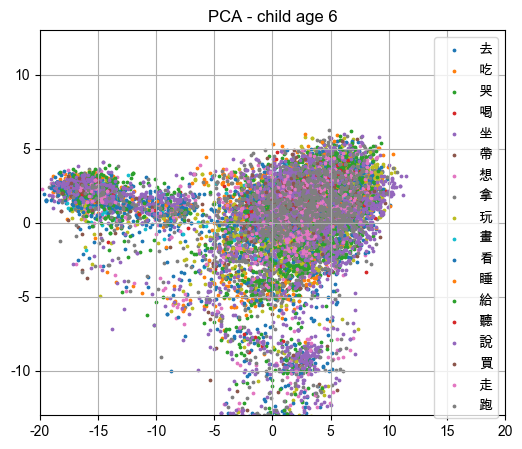

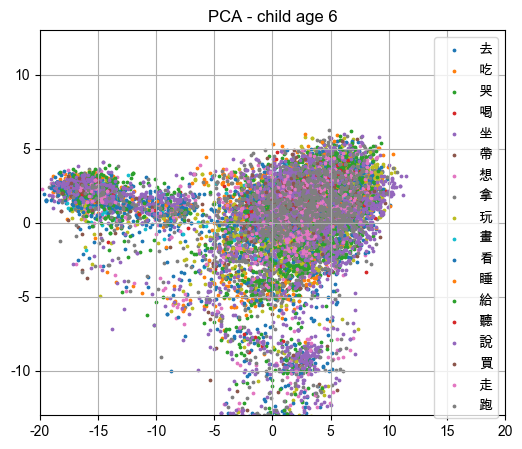

In [38]:
plot_embeddings_pca(char_embeddings_by_group['child']['6'], 'child age 6')

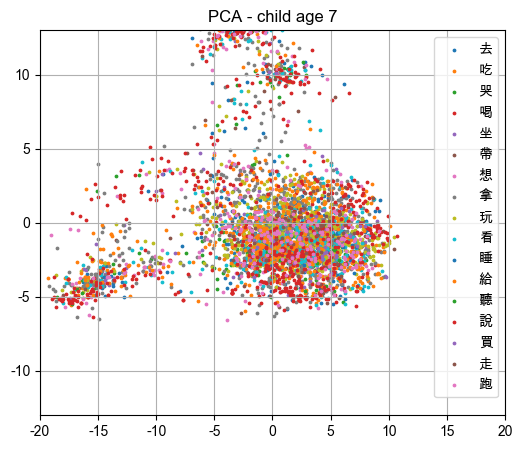

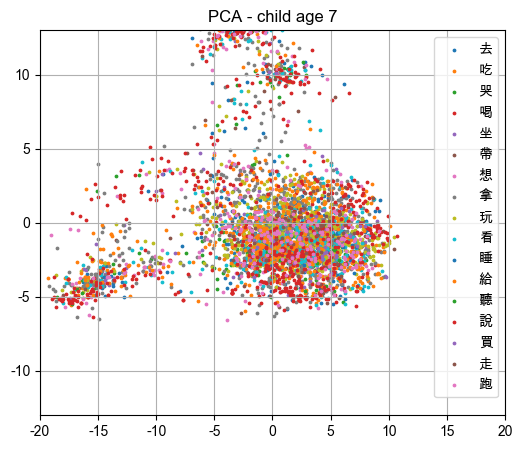

In [39]:
plot_embeddings_pca(char_embeddings_by_group['child']['7'], 'child age 7')

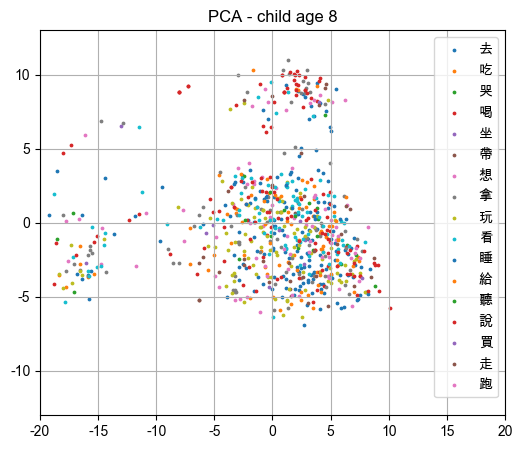

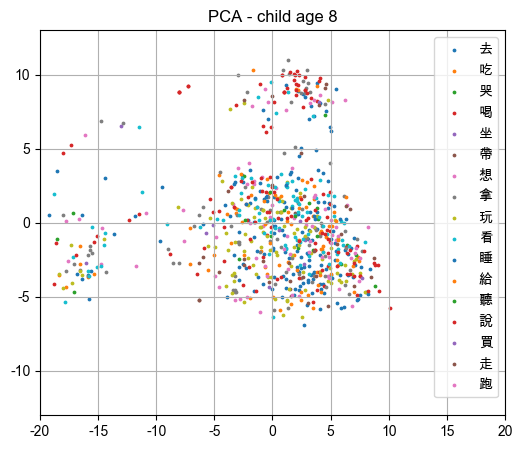

In [40]:
plot_embeddings_pca(char_embeddings_by_group['child']['8'], 'child age 8')

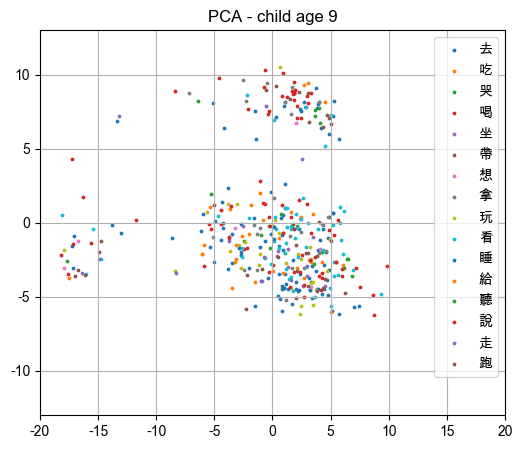

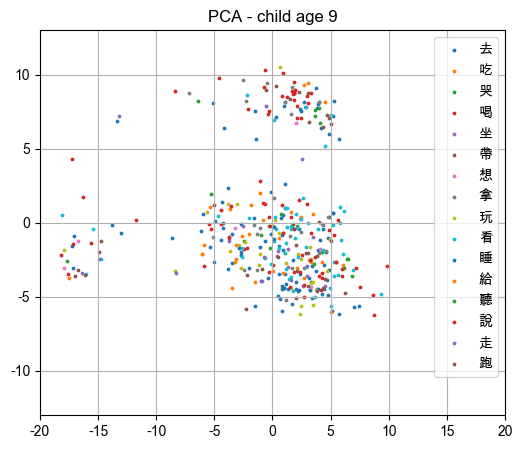

In [41]:
plot_embeddings_pca(char_embeddings_by_group['child']['9'], 'child age 9')

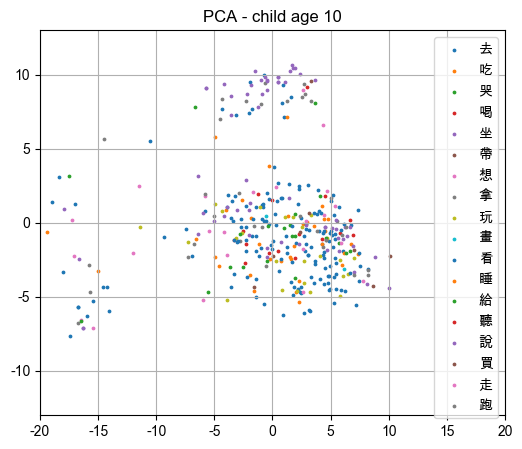

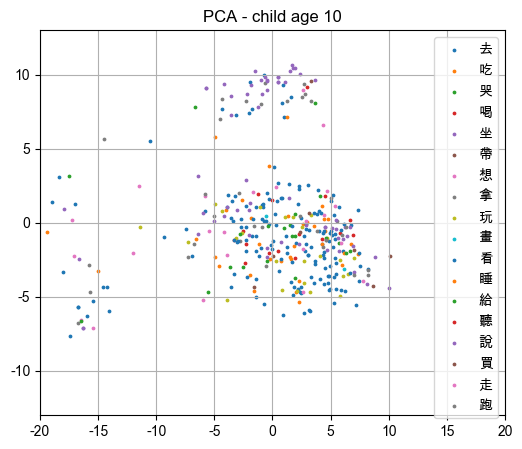

In [42]:
plot_embeddings_pca(char_embeddings_by_group['child']['10'], 'child age 10')

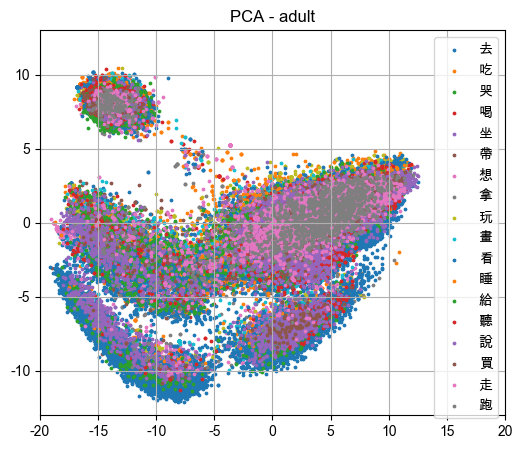

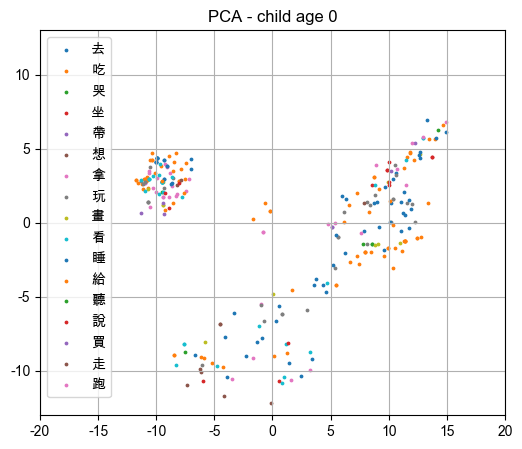

AttributeError: 'list' object has no attribute 'items'

In [43]:
!pip install imageio
import imageio
import io
import matplotlib.pyplot as plt

images = []

# Adults
fig = plot_embeddings_pca(char_embeddings_by_group['adult'], 'adult')
buf = io.BytesIO()
fig.savefig(buf, format='png')
buf.seek(0)
images.append(imageio.v2.imread(buf))
plt.close(fig)
buf.close()

# Children by age (sorted)
for age in sorted(char_embeddings_by_group['child'].keys(), key=int):
    fig = plot_embeddings_pca(char_embeddings_by_group['child'][age], f'child age {age}')
    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    images.append(imageio.v2.imread(buf))
    plt.close(fig)
    buf.close()

imageio.mimsave('embeddings_animation_new.gif', images, fps=1)


In [45]:
from sklearn.cluster import KMeans
import random

def inspect_clusters(group_data, n_clusters=2, n_samples=10):
    embeddings = []
    utterances = []
    chars = []

    for char, vecs in group_data.items():
        for vec, utt in vecs:
            embeddings.append(vec)
            utterances.append(utt)
            chars.append(char)

    if len(embeddings) < n_clusters:
        print("Not enough embeddings for clustering.")
        return

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(embeddings)

    # Group utterances by cluster
    cluster_utterances = {i: [] for i in range(n_clusters)}
    for label, utt, char in zip(labels, utterances, chars):
        cluster_utterances[label].append((char, utt))

    # Print samples
    for i in range(n_clusters):
        print(f"\n--- Cluster {i} ---")
        samples = random.sample(cluster_utterances[i], min(n_samples, len(cluster_utterances[i])))
        for char, utt in samples:
            print(f"[{char}] {utt}")


In [46]:
inspect_clusters(char_embeddings_by_group['adult'], n_clusters=2, n_samples=10)

/Users/deborahwatty/.pyenv/versions/3.12.6/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)



--- Cluster 0 ---
[玩] 我們 來 這裏 玩
[哭] 欣欣 你 為什麼 哭 了 因為 貓咪 不見 了 嗎
[想] 那 你 想 他們 在 幼兒園
[看] 老師 看 到 你 不 聽話 要 說 你 的
[說] 像 我 剛剛 說 香蕉 那樣 和 小 羊 說 一 說 蘋果 好 嗎
[說] 爸爸 說 沒有 怪獸 對不對
[拿] 這 個 這 個 你 也 拿 去 啊
[看] 我們 來 看看 都 有 什麼 大 妖怪
[去] 不 能 再 把 蛋 弄 進去 喔
[說] 吃 晚飯 的時候 我 和 爸爸 媽媽 說 我 要 去 學 空手道

--- Cluster 1 ---
[想] 我 想 起來 了
[看] 看 那麼 多 照片
[去] 一 去 就 沒 你 了
[看] 你 看 這 個 盒子 會 怎麼樣
[看] 看 好 了 啊
[想] 你 想 到 什麼
[看] 你 看 喝 光光
[想] 想起來 了 沒有
[去] 我 去 了 地下室
[看] 你 看


In [47]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import random

def plot_and_sample_clusters(group_data, group_name, n_clusters=3, n_samples=10):
    embeddings = []
    char_labels = []
    utterances = []

    # Unpack (vec, utt) pairs
    for char, vecs in group_data.items():
        for vec, utt in vecs:
            embeddings.append(vec)
            char_labels.append(char)
            utterances.append(utt)

    if len(embeddings) < n_clusters:
        print(f"Not enough data for clustering in {group_name}")
        return

    embeddings = np.vstack(embeddings)

    # PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)

    # KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(embeddings)

    # Plot
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=cluster_labels, cmap='tab10', s=3, alpha=1)
    plt.title(f"PCA with Clusters - {group_name}")
    plt.grid(True)
    plt.ylim((-13, 13))
    plt.xlim((-20, 20))
    plt.colorbar(scatter, ticks=range(n_clusters), label='Cluster')
    plt.show()

    # Print sample utterances
    print(f"\nSample utterances by cluster for {group_name}:")
    cluster_data = {i: [] for i in range(n_clusters)}
    for cluster_id, char, utt in zip(cluster_labels, char_labels, utterances):
        cluster_data[cluster_id].append((char, utt))

    for cluster_id, items in cluster_data.items():
        print(f"\n--- Cluster {cluster_id} ---")
        grouped_by_char = {}
        for char, utt in items:
            grouped_by_char.setdefault(char, []).append(utt)
        for char in sorted(grouped_by_char.keys()):
            examples = random.sample(grouped_by_char[char], min(n_samples, len(grouped_by_char[char])))
            print(f"\n{char}:")
            for ex in examples:
                print("  ", ex)


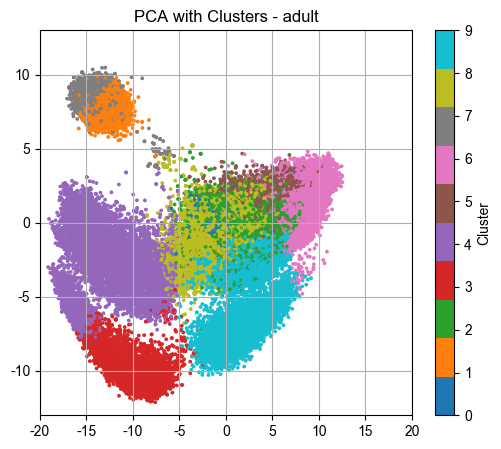


Sample utterances by cluster for adult:

--- Cluster 0 ---

去:
   你 可以 按 門 鈴 進去 哦
   乖乖 你 趴 下去 撿
   乖乖 把 禮賓 車 丟 進去
   媽媽 可能 出去 了
   坐 上去 了 喔
   你 看 他 這樣 本來 就 不 會 掉 下去
   我們 過 去 好吧
   上 個 禮拜 啊 姊姊 就 跟 朋友 出去 吃飯 囉
   放 進去
   嗯 把 南瓜 都 種 進去

吃:
   坐 下 吃
   一共 六 個人 一起 坐 下 吃 飯
   好 了 快 坐 下 吃飯 吧
   坐 下 吃 飯
   他 等下 吃飯 是 吧
   乖乖 坐 下 吃 就 好 了 快 坐 好
   現在 拿 到 哪 個 桌子 上 吃 啊
   坐 下 吃
   然後 這些 小 松鼠 你 知不知道 它 是 要 爬 到 樹 上 吃 松子
   那 我 總 不 好意思 自己 走 進去 坐 下 吃 吧

喝:
   那 給 他 倒 個 茶 吧 給 他們 倒 上 喝 上
   昨天 本來 要 車 上 喝 嗎

坐:
   坐 下 坐 下
   坐 下 坐 下
   來 先 坐 好 往 前 坐 點 好
   荷葉 上 坐 了 一 只 小 青蛙
   好 現在 去 自己 位置 上 坐 好 吃 飯飯 了
   往前 坐 一點 哎
   那 火車 上 坐 什麼 啊

帶:
   你 再 把 它 領 出 帶 出來 玩

想:
   才能 造 出 想 要 的 比如說 桌子 呀 對 吧

拿:
   你 不 是 從 桌子 上 拿 下來 了
   手 往 下 拿 一點
   往 上 拿 一點
   手 往 下 拿 一點
   樓 下 拿 來 啦
   這 個 等 下 拿 給 阿姨
   往 上 拿 一 點
   阿爾丁 從 蛛 網 上 拿 下 這 個 皺 了 皮 的 橡子 般 大小 的 東西

玩:
   好 上 地 上 玩
   通通 收 進 玩具 箱 裡
   這 個 松鼠 在 大 樹 下 玩
   等 下 玩 下 一 個
   吃 完 飯 之後 你 還 要 你 還 要 你 還 要 帶 這些 司機 叔叔 去 山 上 玩 對不對
   在 地 下 玩 啊
   來 來 來 放 在 地 上 玩 吧
   我們 擺 

In [48]:
plot_and_sample_clusters(char_embeddings_by_group['adult'], "adult", n_clusters=10, n_samples=10)


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_sentence_lengths_by_age(data, target_chars):
    records = []

    # Children
    for age, utterances in data["child"].items():
        for utt in utterances:
            tokens = utt.strip().split()
            length = len(tokens)
            for char in target_chars:
                if char in tokens:
                    records.append({
                        "age": age,
                        "char": char,
                        "length": length
                    })

    # Adults
    for utt in data["adult"]:
        tokens = utt.strip().split()
        length = len(tokens)
        for char in target_chars:
            if char in tokens:
                records.append({
                    "age": "adult",
                    "char": char,
                    "length": length
                })

    df = pd.DataFrame(records)

    # Sort ages: numeric ages first, then 'adult' last
    age_order = sorted([a for a in df["age"].unique() if a != "adult"]) + ["adult"]
    df["age"] = pd.Categorical(df["age"], categories=age_order, ordered=True)

    for char in target_chars:
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=df[df["char"] == char], x="age", y="length")
        plt.title(f"Sentence length by age for '{char}'")
        plt.ylabel("Length (words)")
        plt.xlabel("Age")
        plt.grid(True)
        plt.show()


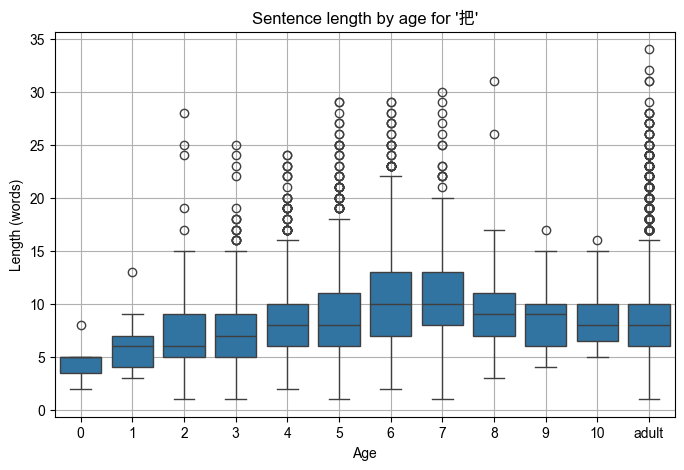

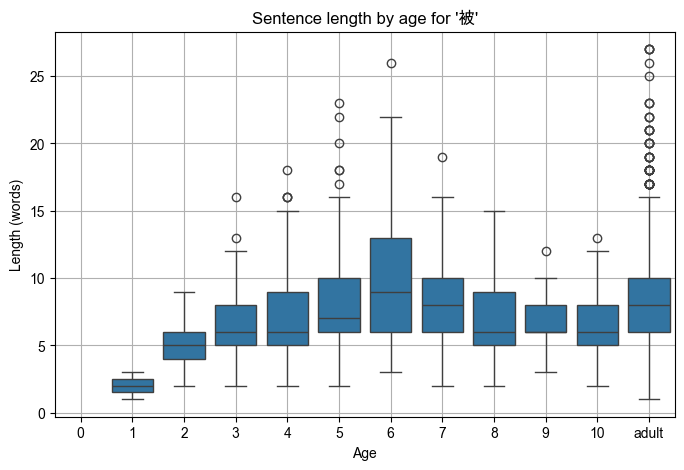

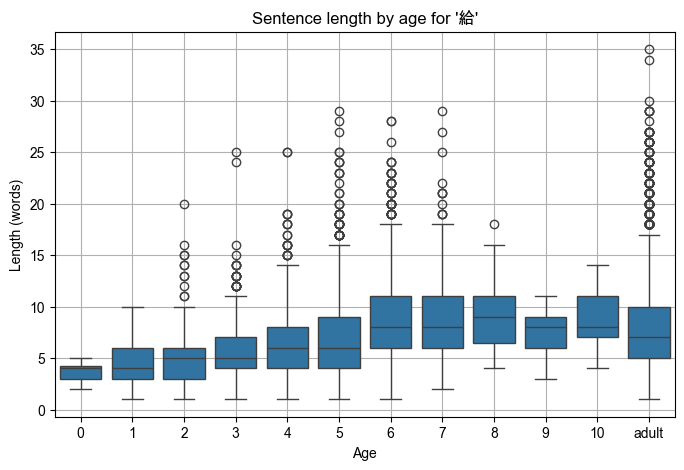

In [50]:
plot_sentence_lengths_by_age(data, ["把", "被", "給"])

In [55]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

def plot_embeddings_pca_with_dbscan(group_data, group_name, eps=0.1, min_samples=40):
    # Flatten and label
    embeddings = []
    labels = []
    utterances = []
    
    for char, vecs in group_data.items():
        embeddings.extend([vec for vec, utt in vecs])
        labels.extend([char] * len(vecs))
        utterances.extend([utt for vec, utt in vecs])
    
    if len(embeddings) < 2:
        print(f"Not enough embeddings for {group_name}")
        return

    # Reduce dimensions
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(np.vstack(embeddings))

    # Apply DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = dbscan.fit_predict(reduced)

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Original plot by character
    ls = list(set(labels))
    ls.sort()
    for char in ls:
        idxs = [i for i, lbl in enumerate(labels) if lbl == char]
        ax1.scatter(reduced[idxs, 0], reduced[idxs, 1], label=char, s=3, alpha=1)
    ax1.set_title(f"PCA by Character - {group_name}")
    ax1.legend()
    ax1.set_ylim((-13,13))
    ax1.set_xlim((-20,20))
    ax1.grid(True)
    
    # DBSCAN clusters plot
    unique_clusters = np.unique(clusters)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
    
    for cluster_id, color in zip(unique_clusters, colors):
        if cluster_id == -1:  # Noise points
            cluster_mask = clusters == cluster_id
            ax2.scatter(reduced[cluster_mask, 0], reduced[cluster_mask, 1], 
                       c='black', s=3, alpha=0.5, label='Noise')
        else:
            cluster_mask = clusters == cluster_id
            ax2.scatter(reduced[cluster_mask, 0], reduced[cluster_mask, 1], 
                       c=[color], s=3, alpha=1, label=f'Cluster {cluster_id}')
    
    ax2.set_title(f"DBSCAN Clusters - {group_name}")
    ax2.legend()
    ax2.set_ylim((-13,13))
    ax2.set_xlim((-20,20))
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print example sentences for each cluster
    print(f"\nCluster Examples for {group_name}:")
    print("=" * 50)
    
    for cluster_id in unique_clusters:
        cluster_mask = clusters == cluster_id
        cluster_utterances = [utterances[i] for i in range(len(utterances)) if cluster_mask[i]]
        cluster_chars = [labels[i] for i in range(len(labels)) if cluster_mask[i]]
        
        if cluster_id == -1:
            print(f"\nNoise Points ({sum(cluster_mask)} points):")
        else:
            print(f"\nCluster {cluster_id} ({sum(cluster_mask)} points):")
        
        # Show up to 5 examples
        for i, (utt, char) in enumerate(zip(cluster_utterances[:5], cluster_chars[:5])):
            print(f"  {char}: {utt}")
        
        if len(cluster_utterances) > 5:
            print(f"  ... and {len(cluster_utterances) - 5} more")
    
    return fig, clusters

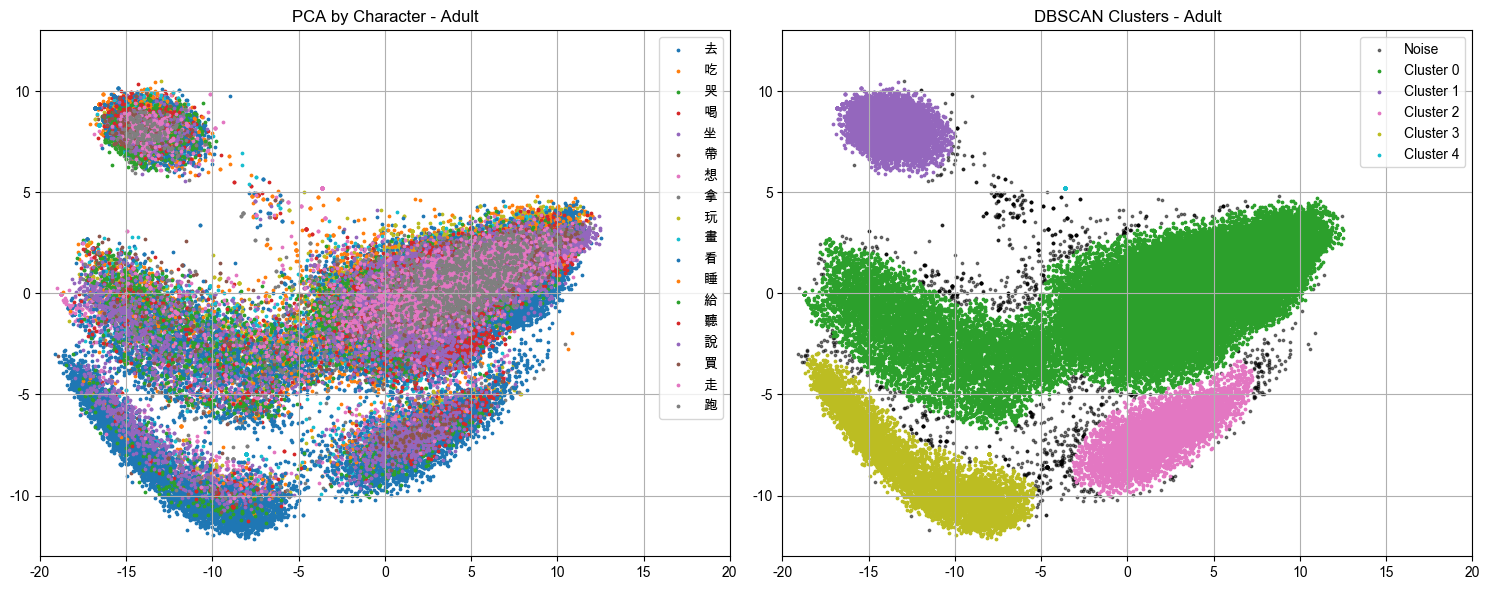


Cluster Examples for Adult:

Noise Points (1211 points):
  聽: 對 聽診器
  聽: 要 聽 的時候 才 會 放 在 耳朵 裡面
  聽: 你 聽 你 聽
  聽: 我 聽 你 媽媽 說 你 有 去 打 過 預防針 喔
  聽: 我 聽 你 媽媽 說 她 有 帶 你 去 花蓮 海洋 公園 玩
  ... and 1206 more

Cluster 0 (91872 points):
  聽: 你 小時候 明明 也 有 聽診器 啊
  聽: 幫 你 聽聽 肚子
  聽: 幫 你 聽聽 肚子
  聽: 幫 他 聽聽看
  聽: 幫 他 聽聽看
  ... and 91867 more

Cluster 1 (11651 points):
  聽: 聽 完 聽 完 就 檢查 完畢
  聽: 聽
  聽: 聽 一下
  聽: 聽 診 也 沒用 到 啊 醫生
  聽: 聽診器 是 用來 幹嘛 的
  ... and 11646 more

Cluster 2 (6088 points):
  聽: 醫生 你 聽 了 之後 我 怎麼 了 嗎
  聽: 那 醫生 你 聽 到 什麼 了
  聽: 那 我 幫 你 聽 一下 好了 好 嗎
  聽: 那 你 聽 到 了 什麼
  聽: 你 要 當 醫生 那 給 你 聽診器
  ... and 6083 more

Cluster 3 (8454 points):
  聽: 你 聽聽看
  聽: 你 聽 自己 肚子
  聽: 你 聽 到 咕嚕 咕嚕 是不是
  聽: 你 聽 不 懂 嗎
  聽: 你 聽 我
  ... and 8449 more

Cluster 4 (50 points):
  想: 想一想
  想: 想一想
  想: 想一想
  想: 想一想
  想: 想一想
  ... and 45 more


In [66]:
fig, clusters = plot_embeddings_pca_with_dbscan(char_embeddings_by_group['adult'], "Adult", eps=0.5, min_samples=50)

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import json
import random
plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

def plot_embeddings_pca_with_dbscan(group_data, group_name, eps=0.1, min_samples=40):
    # Flatten and label
    embeddings = []
    labels = []
    utterances = []
    
    for char, vecs in group_data.items():
        embeddings.extend([vec for vec, utt in vecs])
        labels.extend([char] * len(vecs))
        utterances.extend([utt for vec, utt in vecs])
    
    if len(embeddings) < 2:
        print(f"Not enough embeddings for {group_name}")
        return

    # Reduce dimensions
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(np.vstack(embeddings))

    # Apply DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = dbscan.fit_predict(reduced)

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Original plot by character
    ls = list(set(labels))
    ls.sort()
    for char in ls:
        idxs = [i for i, lbl in enumerate(labels) if lbl == char]
        ax1.scatter(reduced[idxs, 0], reduced[idxs, 1], label=char, s=3, alpha=1)
    ax1.set_title(f"PCA by Character - {group_name}")
    ax1.legend()
    ax1.set_ylim((-13,13))
    ax1.set_xlim((-20,20))
    ax1.grid(True)
    
    # DBSCAN clusters plot
    unique_clusters = np.unique(clusters)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
    
    for cluster_id, color in zip(unique_clusters, colors):
        if cluster_id == -1:  # Noise points
            cluster_mask = clusters == cluster_id
            ax2.scatter(reduced[cluster_mask, 0], reduced[cluster_mask, 1], 
                       c='black', s=3, alpha=0.5, label='Noise')
        else:
            cluster_mask = clusters == cluster_id
            ax2.scatter(reduced[cluster_mask, 0], reduced[cluster_mask, 1], 
                       c=[color], s=3, alpha=1, label=f'Cluster {cluster_id}')
    
    ax2.set_title(f"DBSCAN Clusters - {group_name}")
    ax2.legend()
    ax2.set_ylim((-13,13))
    ax2.set_xlim((-20,20))
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Create JSON with all classifications
    cluster_data = {}
    for i, (utt, char, cluster_id) in enumerate(zip(utterances, labels, clusters)):
        if cluster_id not in cluster_data:
            cluster_data[cluster_id] = []
        cluster_data[cluster_id].append({"utterance": utt, "character": char})
    
    # Print 25 random examples per cluster
    print(f"\nCluster Examples for {group_name}:")
    print("=" * 50)
    
    for cluster_id in unique_clusters:
        cluster_items = cluster_data[cluster_id]
        
        if cluster_id == -1:
            print(f"\nNoise Points ({len(cluster_items)} points):")
        else:
            print(f"\nCluster {cluster_id} ({len(cluster_items)} points):")
        
        # Show up to 25 random examples
        sample_size = min(25, len(cluster_items))
        samples = random.sample(cluster_items, sample_size)
        
        for item in samples:
            print(f"  {item['character']}: {item['utterance']}")
        
        if len(cluster_items) > 25:
            print(f"  ... and {len(cluster_items) - 25} more")
    
    return fig, clusters, cluster_data


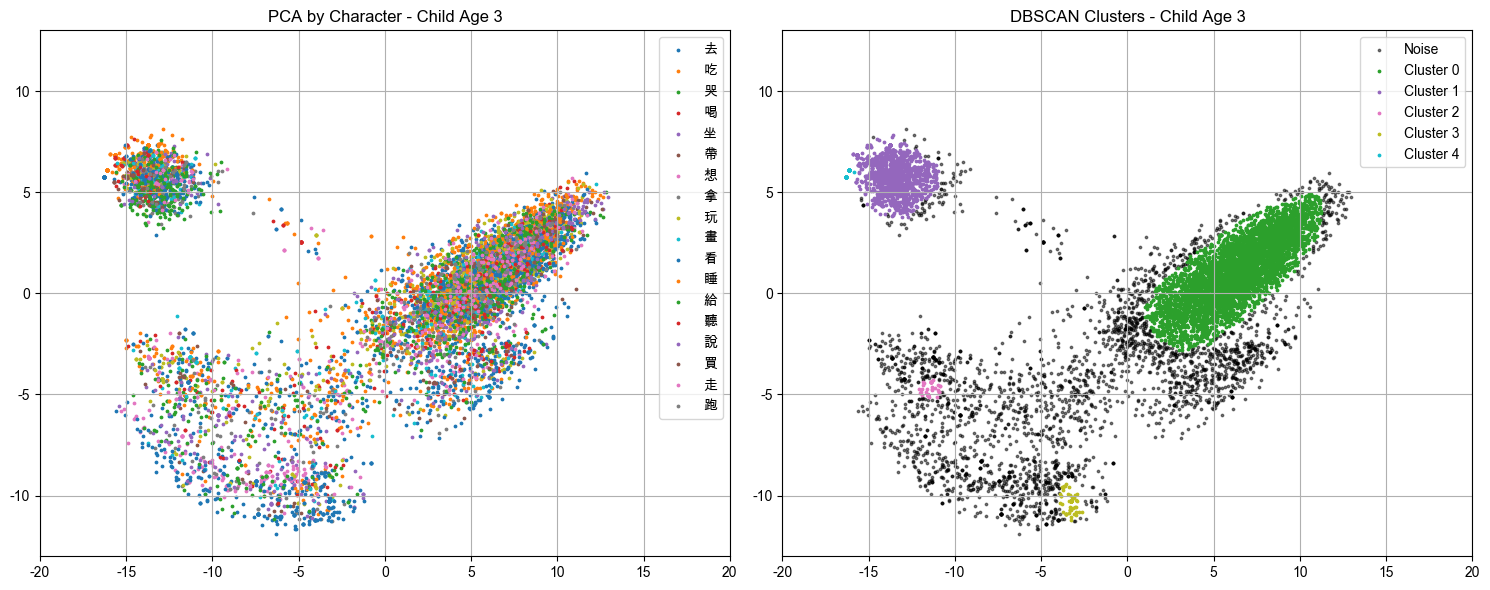


Cluster Examples for Child Age 3:

Noise Points (2732 points):
  想: 啊 我 想 到 了
  畫: 那 畫 在 這裏
  吃: 嚼 吃 把 皮 拿 掉 吃
  買: 去 買 水果 時候 老師 就 會 看見 蘋果 還有 香蕉
  吃: 還有 一 個 留 吃
  去: 牛油果 我 去 找 一 找 吧
  坐: 媽 你 坐 我 的 車 吧
  吃: 再 吃 一 個 山楂
  玩: 他 說 不 要 我 不 要 跟 你 玩
  說: 現在 他 說 什麼
  看: 我 看
  給: 給 我 給 我
  看: 啊 我 算 看看
  看: 你 看 你
  玩: 我 想 和 你 玩
  看: 我 看 到 一 艘 太空船 了
  想: 我 想 搭 一 個 鎖
  吃: 魚 要 吃 飯飯
  說: 媽媽 說 明天 要 去 美國
  買: 這 個 是 我 買 的
  吃: 都 有 菜 吃 的
  想: 我 想 用 藍 顏色 的 畫
  看: 老師 說 咚咚 給 你 看
  睡: 睡 睡覺 睡覺
  去: 出去 了
  ... and 2707 more

Cluster 0 (4577 points):
  去: 阿姨 帶 小朋友 去 聽聽 海 邊 看 大 輪船
  喝: 嗯 他 也 要 喝
  玩: 這 個 積木 很 難 玩
  去: 從 靠 在 一起 的 積木 中間 的 缺口 看 出去
  想: 小熊維尼 不 想 聽 這 種 吧
  畫: 我 還 想 畫 蘋果
  去: 從 這 關 掉 去
  坐: 還有 車子 可以 坐 上去
  吃: 阿姨 我 要 吃 一點 東西
  看: 牠 爸爸 去 看 那裏 有 壞 人
  看: 不 要 看 這 個
  畫: 我 想 畫 畫 個 紫 顏色 的
  吃: 不 不 可以 吃 泡泡 啊
  玩: 好 好玩 哦
  拿: 這 只 拿 掉
  聽: 我 我們 聽聽 這 個
  玩: 不 能 到 外面 玩
  看: 我 看看
  玩: 我 想 玩 那 個
  畫: 玫瑰 紅 畫 畫 一 個 音海大王
  拿: 那 我 去 拿 一 個 真的 球
  坐: 這 個 都 可以 坐 呀
  吃: 我們 就 沒有 吃飯 呢
  去: 從 這 個 裡面 進去
  玩: 又 到 一 個 地方 玩 了
 

In [81]:
fig, clusters, cluster_data = plot_embeddings_pca_with_dbscan(char_embeddings_by_group['child']['3'], "Child Age 3", eps=0.5, min_samples=50)

In [82]:
cluster_data

{0: [{'utterance': '丟 進去', 'character': '去'},
  {'utterance': '就 可以 溜 下去', 'character': '去'},
  {'utterance': '玩具 陪 我 睡覺 去', 'character': '去'},
  {'utterance': '前面 的 就 可以 爬 上去', 'character': '去'},
  {'utterance': '小朋友 可以 爬 上去', 'character': '去'},
  {'utterance': '然後 跟 我 想 到 去 拼 在 這裏 不是', 'character': '去'},
  {'utterance': '這 個 蓋 上去 了', 'character': '去'},
  {'utterance': '坐 船 去 游泳 吧', 'character': '去'},
  {'utterance': '我 我 我 放 進去', 'character': '去'},
  {'utterance': '我 要 去 這邊', 'character': '去'},
  {'utterance': '我 要 這樣子 放 回去', 'character': '去'},
  {'utterance': '這 這 這 個 打針 打 下去', 'character': '去'},
  {'utterance': '從 上面 飛 過去', 'character': '去'},
  {'utterance': '好 那 他 進 得 去 嗎', 'character': '去'},
  {'utterance': '爸爸 去 上班 了', 'character': '去'},
  {'utterance': '嗯 下去', 'character': '去'},
  {'utterance': '這 是 凹 進去 嗎', 'character': '去'},
  {'utterance': '要 怎麼 戴 進去', 'character': '去'},
  {'utterance': '嗯 這 是 爬 上去', 'character': '去'},
  {'utterance': '嗯 收 回去', 'character': '去'},
  {'utteran

/var/folders/nh/hvm_mtd520gb8x3t27vhm0_h0000gp/T/ipykernel_51982/3763265410.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


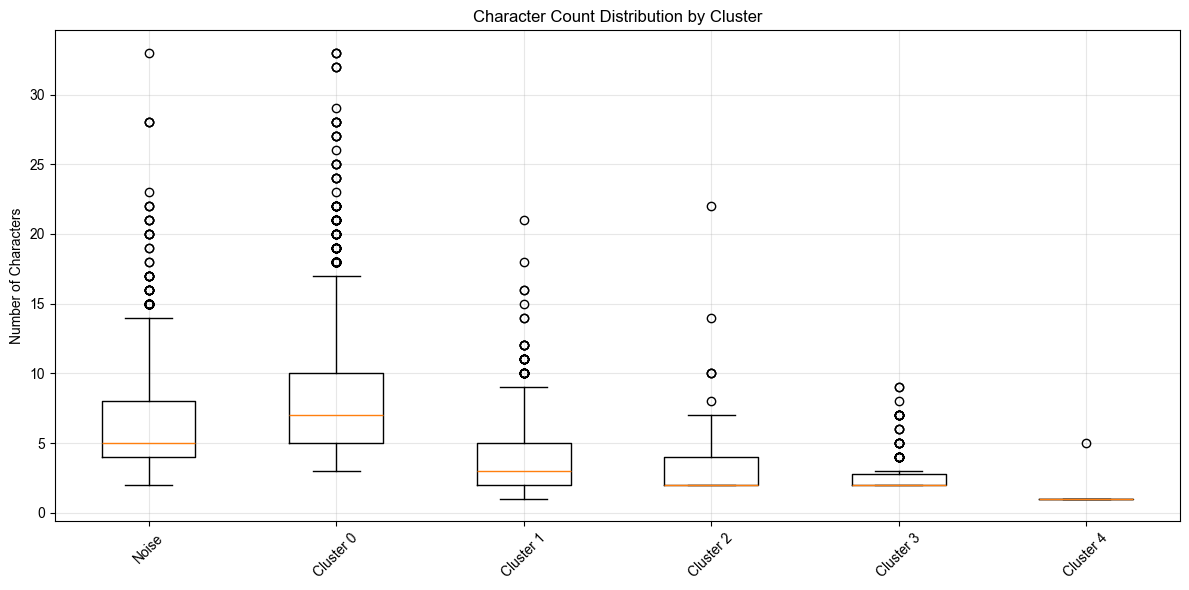

In [83]:
import matplotlib.pyplot as plt

# Calculate character counts per sentence for each cluster
cluster_lengths = {}
for cluster_id, items in cluster_data.items():
    lengths = [len(item['utterance'].replace(' ', '')) for item in items]
    cluster_lengths[cluster_id] = lengths

# Create box plot
plt.figure(figsize=(12, 6))
data_to_plot = [cluster_lengths[cluster_id] for cluster_id in sorted(cluster_lengths.keys())]
labels = [f'Cluster {cluster_id}' if cluster_id != -1 else 'Noise' for cluster_id in sorted(cluster_lengths.keys())]

plt.boxplot(data_to_plot, labels=labels)
plt.ylabel('Number of Characters')
plt.title('Character Count Distribution by Cluster')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


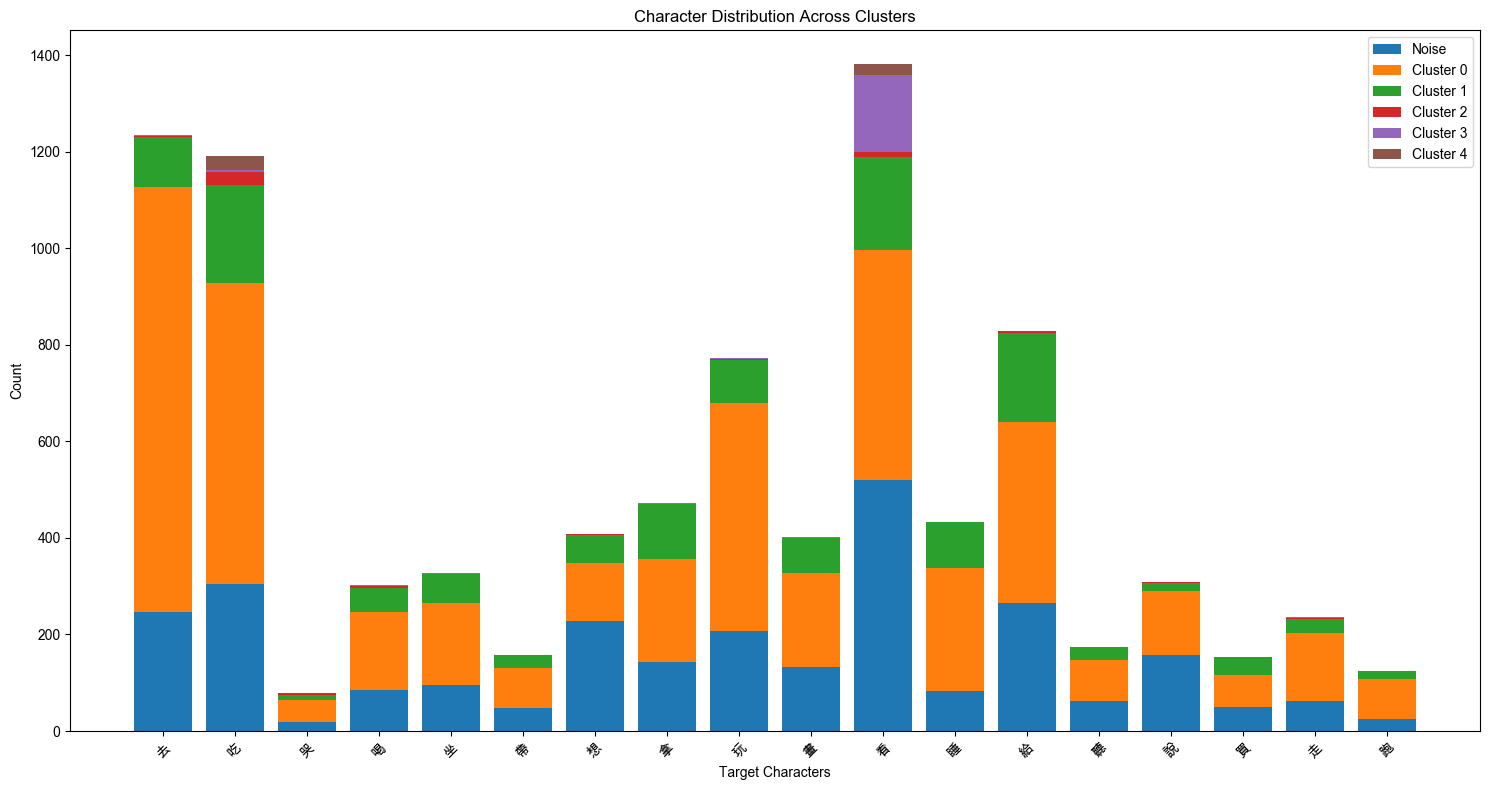

In [84]:
from collections import defaultdict
import matplotlib.pyplot as plt

# Count characters by cluster
char_cluster_counts = defaultdict(lambda: defaultdict(int))
for cluster_id, items in cluster_data.items():
    for item in items:
        char_cluster_counts[item['character']][cluster_id] += 1

# Prepare data for stacked bar chart
characters = sorted(char_cluster_counts.keys())
cluster_ids = sorted(set(cluster_id for counts in char_cluster_counts.values() for cluster_id in counts.keys()))

# Create matrix for stacked bars
data_matrix = []
for cluster_id in cluster_ids:
    row = [char_cluster_counts[char][cluster_id] for char in characters]
    data_matrix.append(row)

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(15, 8))
bottom = [0] * len(characters)

for i, cluster_id in enumerate(cluster_ids):
    label = f'Cluster {cluster_id}' if cluster_id != -1 else 'Noise'
    ax.bar(characters, data_matrix[i], bottom=bottom, label=label)
    bottom = [b + d for b, d in zip(bottom, data_matrix[i])]

ax.set_xlabel('Target Characters')
ax.set_ylabel('Count')
ax.set_title('Character Distribution Across Clusters')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [1]:
from load_embeddings import load_char_embeddings
char_embeddings_by_group = load_char_embeddings(input_dir="char_embeddings_by_group_all_with_utts_20")

In [2]:
from umap import UMAP
import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import random

plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

def plot_embeddings_umap_with_hdbscan(group_data, group_name, n_neighbors=15, min_dist=0.1, min_cluster_size=40):
    # Flatten and label
    embeddings = []
    labels = []
    utterances = []
    
    for char, vecs in group_data.items():
        embeddings.extend([vec for vec, utt in vecs])
        labels.extend([char] * len(vecs))
        utterances.extend([utt for vec, utt in vecs])
    
    if len(embeddings) < 2:
        print(f"Not enough embeddings for {group_name}")
        return

    X = np.vstack(embeddings)

    # --- UMAP reduction to 2D ---
    reducer = UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, random_state=42)
    reduced = reducer.fit_transform(X)

    # --- HDBSCAN clustering ---
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
    clusters = clusterer.fit_predict(reduced)

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot by character
    ls = sorted(set(labels))
    for char in ls:
        idxs = [i for i, lbl in enumerate(labels) if lbl == char]
        ax1.scatter(reduced[idxs, 0], reduced[idxs, 1], label=char, s=3, alpha=1)
    ax1.set_title(f"UMAP by Character - {group_name}")
    ax1.legend()
    ax1.grid(True)
    
    # Plot clusters
    unique_clusters = np.unique(clusters)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
    
    for cluster_id, color in zip(unique_clusters, colors):
        cluster_mask = clusters == cluster_id
        if cluster_id == -1:  # Noise
            ax2.scatter(reduced[cluster_mask, 0], reduced[cluster_mask, 1], 
                        c='black', s=3, alpha=0.5, label='Noise')
        else:
            ax2.scatter(reduced[cluster_mask, 0], reduced[cluster_mask, 1], 
                        c=[color], s=3, alpha=1, label=f'Cluster {cluster_id}')
    
    ax2.set_title(f"HDBSCAN Clusters - {group_name}")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

    # --- Collect cluster data ---
    cluster_data = {}
    for utt, char, cluster_id in zip(utterances, labels, clusters):
        cluster_data.setdefault(cluster_id, []).append({"utterance": utt, "character": char})
    
    # --- Print examples ---
    print(f"\nCluster Examples for {group_name}:")
    print("=" * 50)
    
    for cluster_id in unique_clusters:
        cluster_items = cluster_data[cluster_id]
        if cluster_id == -1:
            print(f"\nNoise Points ({len(cluster_items)} points):")
        else:
            print(f"\nCluster {cluster_id} ({len(cluster_items)} points):")
        
        sample_size = min(25, len(cluster_items))
        samples = random.sample(cluster_items, sample_size)
        
        for item in samples:
            print(f"  {item['character']}: {item['utterance']}")
        
        if len(cluster_items) > 25:
            print(f"  ... and {len(cluster_items) - 25} more")
    
    return fig, clusters, cluster_data


/Users/deborahwatty/.pyenv/versions/3.12.6/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/deborahwatty/.pyenv/versions/3.12.6/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/deborahwatty/.pyenv/versions/3.12.6/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/deborahwatty/.pyenv/versions/3.12.6/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


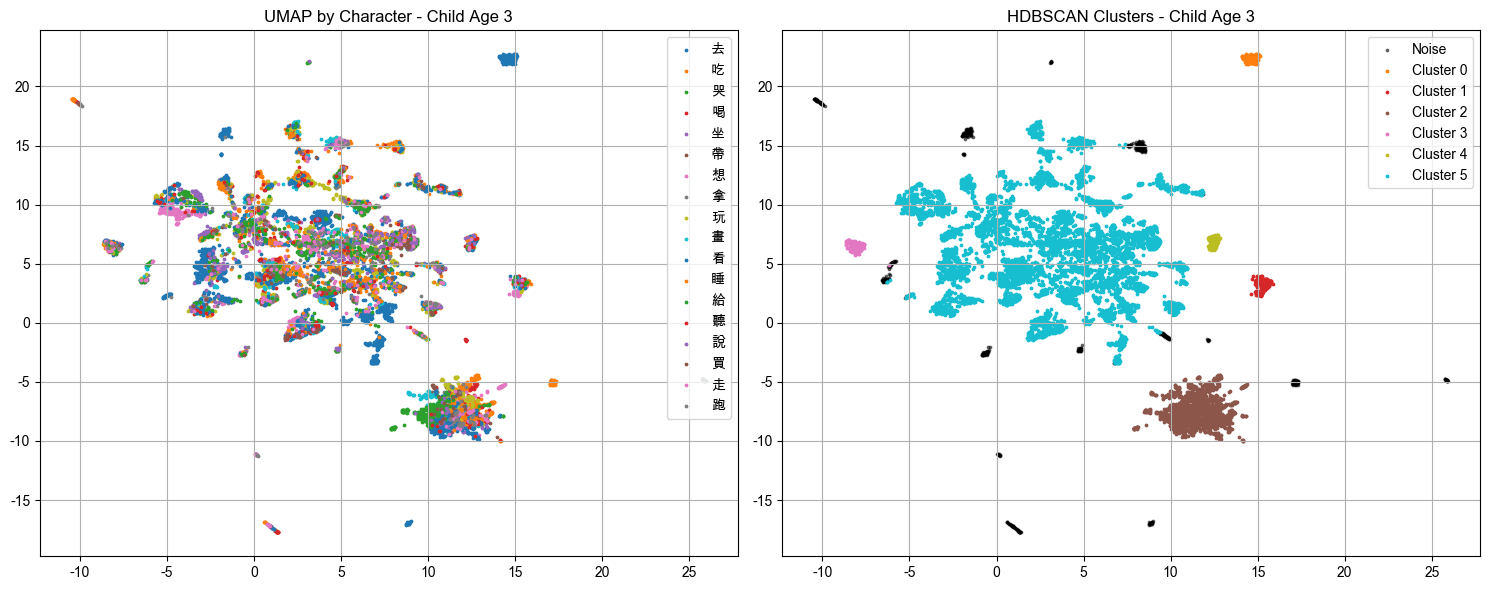


Cluster Examples for Child Age 3:

Noise Points (554 points):
  走: 我 先 走 呀
  說: 老師 說 老師 說 是 蘋果
  給: 乖 送 你 一 件 小的 給 你 穿
  給: 我們 先 給 她 燒 一 碗 菜 好不好
  給: 先 給 胡蘿蔔 放 了
  說: 說
  去: 怎麼 樣 才 能 出去 呀
  睡: 睡覺
  吃: 吃
  給: 先 給 她 先 給 她 吃 飯 啊
  玩: 嗯 我 想 想 先 玩 玩 這 個
  給: 姨婆 的 給 我
  拿: 拿 先 拿 鋼琴 來
  睡: 她 也 睡覺
  睡: 睡覺
  去: 但是 那 是 我們 以前 出去 玩 的
  睡: 睡
  看: 我 要 自己 看
  睡: 睡覺 的 地方
  走: 走 上 去
  哭: 哇 哇哇 學 娃娃 的 哭聲
  去: 吃 完 飯 你 想 出去 玩 嗎
  去: 有一天 他們 出去 玩兒 了
  吃: 吃
  給: 好的 給 豬 爸爸 刷刷 牙
  ... and 529 more

Cluster 0 (133 points):
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  ... and 108 more

Cluster 1 (138 points):
  想: 我 很 想 你
  想: 我 不 想 跟
  帶: 就是 瞎 跑 不 帶 她 來 了
  睡: 為什麼 不 睡覺 嗎
  想: 我 不 想 吃 了
  去: 紅 燈 也 過不去 綠 燈 也 過不去
  給: 我 不 給 你 看
  想: 我 不 想 畫 其它 顏色 的
  給: 軒軒 軒軒 不 給 媽媽 進來 啦
  給: 我 不 給 你 吃
  吃: 所以 小 熊 就 不 吃 了
  坐: 小 豬 也 不 坐 了
  想: 我 不 想 玩 

In [6]:
fig, clusters, cluster_data = plot_embeddings_umap_with_hdbscan(
    char_embeddings_by_group['child']['3'], 
    "Child Age 3", 
    n_neighbors=15, 
    min_dist=0.5, 
    min_cluster_size=100
)

/Users/deborahwatty/.pyenv/versions/3.12.6/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/deborahwatty/.pyenv/versions/3.12.6/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/deborahwatty/.pyenv/versions/3.12.6/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/nh/hvm_mtd520gb8x3t27vhm0_h0000gp/T/ipykernel_94160/3018793677.py:64: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


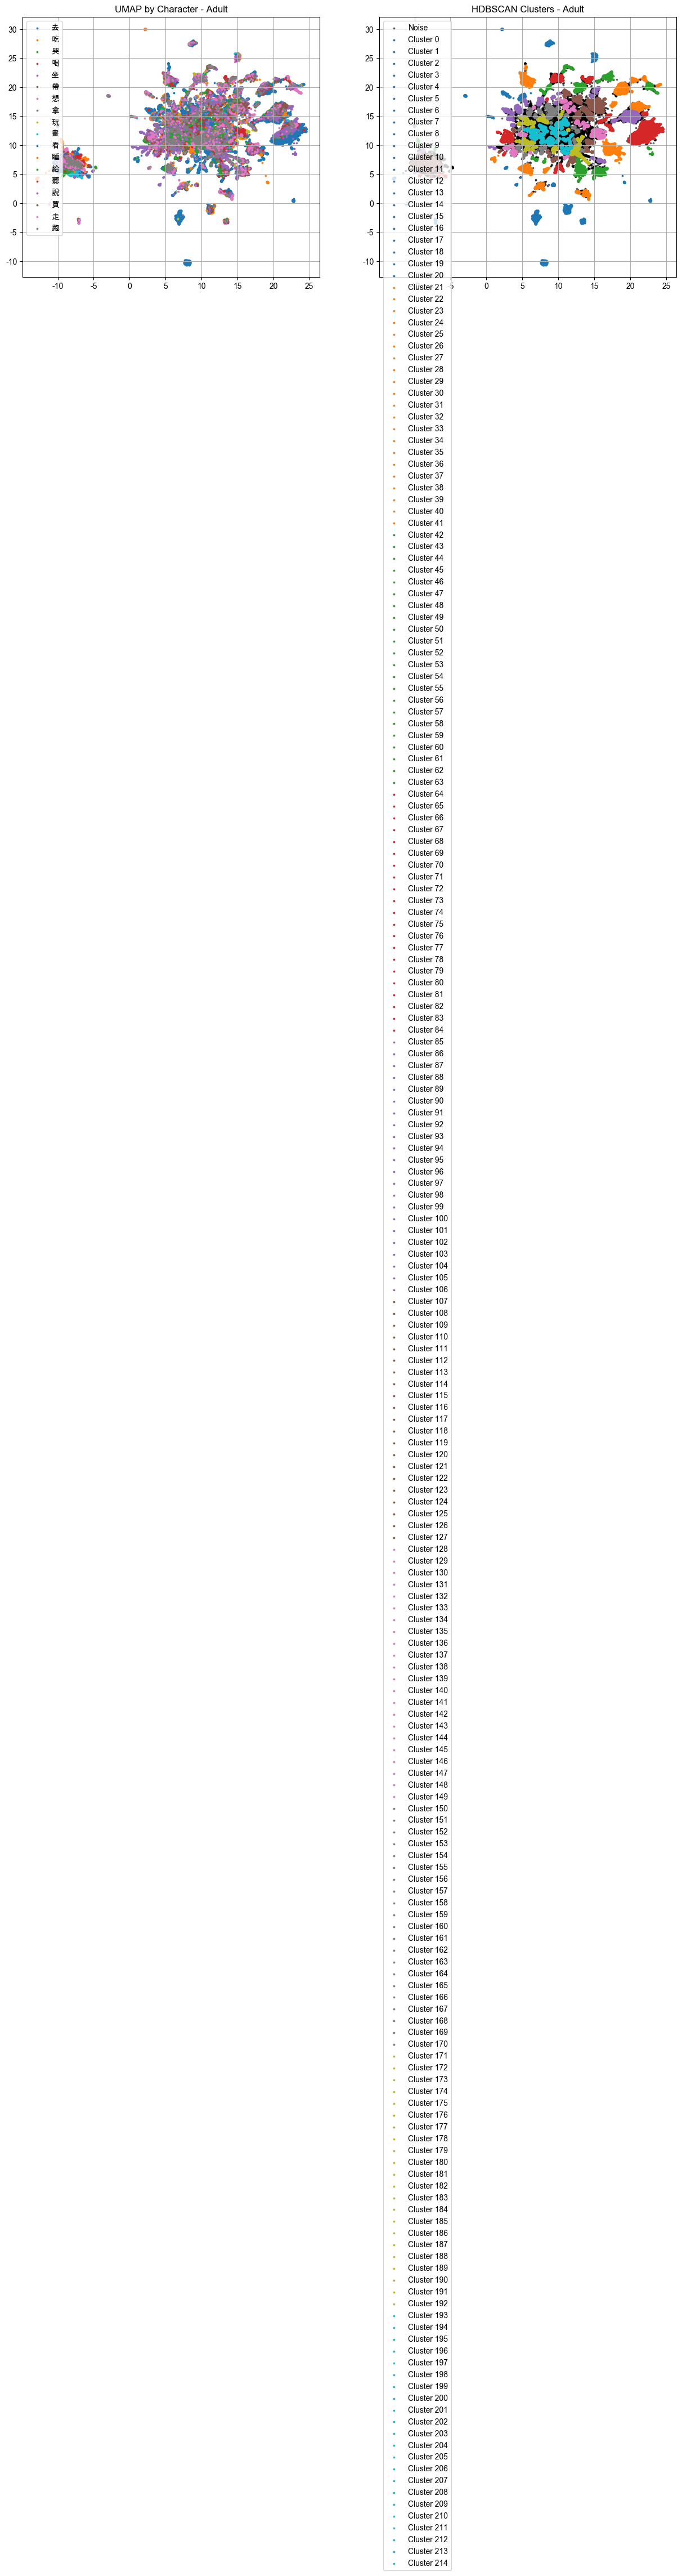


Cluster Examples for Adult:

Noise Points (15639 points):
  吃: 快 吃
  吃: 快 吃 飯
  去: 主人 上班 去 了
  看: 你 看看 撒
  想: 想 要 大 樹 我們 需要 幹嘛
  吃: 嗯 喂 貓 吃吃 對
  說: 再 說 一 次
  去: 正巧 有一天 他 幹嘛 去 呀
  看: 有一次 你 去 看 醫生 的時候 發生 了 什麼 事
  去: 哇 原來 小 寶貝 從 上面 掉 到 一 個 下面 地下室 去 了
  給: 來 小 半 圓形 給 你
  給: 對 給 它 洗 完 澡 然後 是 幹嘛 呀
  吃: 好 了 媽媽 也 開 吃 了
  吃: 吃 過 晚飯
  說: 說 的 太 棒 了
  看: 我們 去 看看 兔子 媽媽 種 了 什麼 吧
  看: 你 看 你 看 你 看 你 看 你 看
  給: 那 上 鋪 到底 給 誰 睡 呢
  吃: 茄子 吃 不 吃
  吃: 哇 這 個 是 吃 吃 吃 早餐 的 湯匙 對不對
  給: 它 也 沒 地方 住 給 他 來 把 椅子 吧 給 他 一 把 小 的 吧
  看: 你 吃 吃 看 這 個 獅子 頭 好吃 嗎 味道 怎麼樣 丁曄佳
  想: 想 要 的 果實 你 希望 吃 哪些 果實
  走: 走 吧
  去: 所以 他 從來 不 去 那裏
  ... and 15614 more

Cluster 0 (962 points):
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  看: 你 看
  ... and 937 more

Cluster 1 (85 points):
  吃: 可是 爸爸 媽媽 一 走 這 只 皮皮鼠 還是 忍不住 吃 了 跳跳糖
  吃: 可是 爸爸 媽媽 一 走 兩 只 皮皮鼠 又 忍不住 吃 了 跳跳糖
  吃: 三 

In [8]:
fig, clusters, cluster_data = plot_embeddings_umap_with_hdbscan(
    char_embeddings_by_group['adult'], 
    "Adult", 
    n_neighbors=80, 
    min_dist=0.5, 
    min_cluster_size=50
)